### VSG

In [1]:
import gc
import glob
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

import dask
from dask.diagnostics import ProgressBar
from IPython.display import HTML
from tqdm import tqdm

sys.path.append('..')
from src.utils import parse_ncf_stack_filename
from src.ncf import get_vs_number, export_targeted_ncfs, fast_batch_processor, split_ncf_sides_for_dispersion
from src.plots import (plot_ncf, plot_directional_ncf, plot_preprocessed_ncf, plot_preprocessed_fk,
                       animate_ncf_section_mesh, animate_directional_ncf_section_mesh, animate_preprocessed_ncf, animate_preprocessed_fk, animate_pipeline)

import matplotlib as mpl
mpl.rcParams["animation.html"] = "jshtml"
mpl.rcParams["animation.embed_limit"] = 500.0 

old_fig_dpi = plt.rcParams['figure.dpi']
old_save_dpi = plt.rcParams['savefig.dpi']

#### 1. Read NCFs

In [2]:
# Choose dataset
pattern_v1_15d = "../data/ncf_stacks_urban/15d/20210914_cc_*_15d_v1.npy"

files_v1 = sorted(glob.glob(pattern_v1_15d), key=get_vs_number)

print("Matched files:", len(files_v1))
print(f"First 3 files: {[os.path.basename(f) for f in files_v1[:3]]}")
print(f"Last 3 files: {[os.path.basename(f) for f in files_v1[-3:]]}")

print("Matched files:", len(files_v1))
print(f"First 3 files: {[os.path.basename(f) for f in files_v1[:3]]}")
print(f"Last 3 files: {[os.path.basename(f) for f in files_v1[-3:]]}")

Matched files: 35
First 3 files: ['20210914_cc_000_15d_v1.npy', '20210914_cc_010_15d_v1.npy', '20210914_cc_020_15d_v1.npy']
Last 3 files: ['20210914_cc_320_15d_v1.npy', '20210914_cc_330_15d_v1.npy', '20210914_cc_340_15d_v1.npy']
Matched files: 35
First 3 files: ['20210914_cc_000_15d_v1.npy', '20210914_cc_010_15d_v1.npy', '20210914_cc_020_15d_v1.npy']
Last 3 files: ['20210914_cc_320_15d_v1.npy', '20210914_cc_330_15d_v1.npy', '20210914_cc_340_15d_v1.npy']


In [3]:
# 1. Load ONE file to infer axes 
# We only need one representative NCF to build lag_axis & distance_axis
ncf0_path = files_v1[0]
ncf0 = np.load(ncf0_path)

# Parse metadata (date, vs, window, mode)
date0, vs0, window0, mode0 = parse_ncf_stack_filename(ncf0_path)
print("Example parsed:", date0, vs0, window0, mode0)

Example parsed: 20210914 000 15d v1


In [4]:
# 2. Define parameters
fs = 250        # Sampling frequency in Hz
dt = 1 / fs     # sampling rate in sec

max_lag = 2.0     # seconds
npts_lag = int(max_lag * fs)

# Array configuration
first_chan = 399
last_chan = 748
dx = 8.16
channels = np.arange(first_chan, last_chan + 1)

n_rec = len(channels)
lag_axis = np.linspace(-max_lag, +max_lag, ncf0.shape[1])  
distance_axis = (channels - channels[0]) * dx

print(f"NCF shape: {ncf0.shape}, Lag axis: {lag_axis.shape}, Distance axis: {distance_axis.shape}")

NCF shape: (350, 1001), Lag axis: (1001,), Distance axis: (350,)


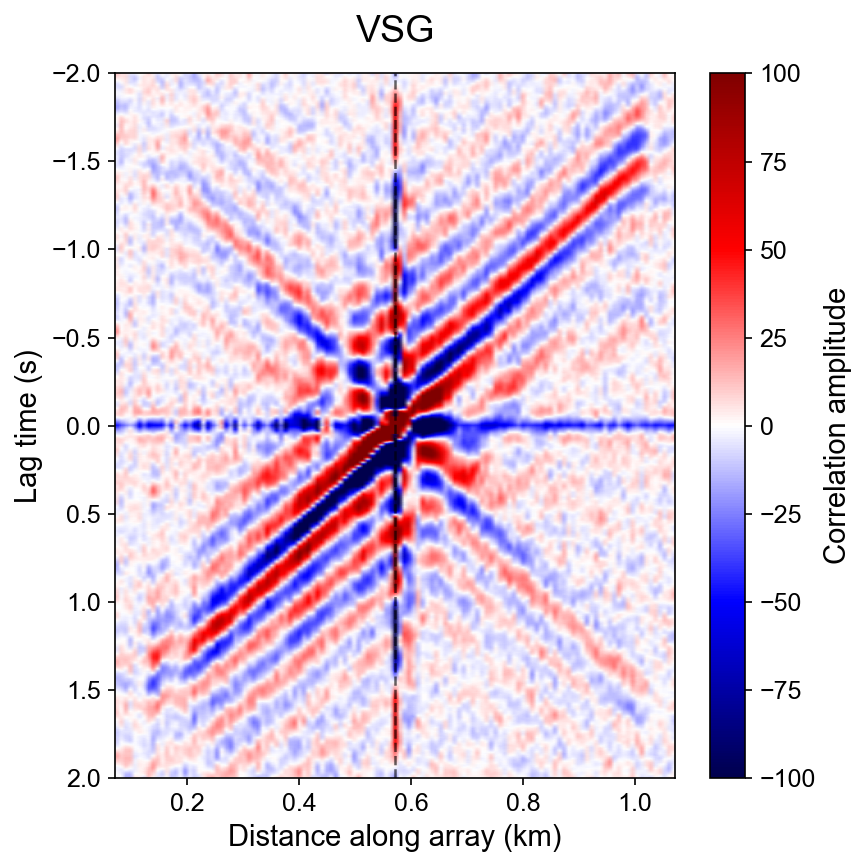

In [5]:
fig, ax = plot_ncf(
    pattern_v1_15d,
    VS=70,                   
    lag_axis=lag_axis,
    distance_axis=distance_axis,
    mode="all",
    unit="km",
    pclip=99.5,
    dx=dx,
    range_m=500,
    clip_lim=True,
    figsize=(6, 6),
    title="VSG",
    show_cbar=True,
    dpi=150
)

plt.show()

In [ ]:
try:
    # Force global DPI down just for this rendering phase
    plt.rcParams.update({
        'figure.dpi': 120,        
        'savefig.dpi': 120,
        'axes.titlesize': 14,
    })

    # Generate the animation
    ani = animate_ncf_section_mesh(
        pattern_v1_15d,
        lag_axis=lag_axis,
        distance_axis=distance_axis,
        mode="all",
        unit="km",
        pclip=99,
        dx=dx,
        range_m=500,
        clip_lim=True,
        interval_ms=150,
        figsize=(6, 6)   
    )
    
    # Render the HTML while the low-DPI settings are still active
    output = HTML(ani.to_jshtml())

finally:
    # Safely restore high-res settings for other plots
    plt.rcParams.update({
        'figure.dpi': old_fig_dpi,
        'savefig.dpi': old_save_dpi,
    })

# Display the output
display(output)

# Aggressive memory cleanup
# Kill the hidden matplotlib figure canvas
plt.close('all')

# Delete the heavy python objects (the animation and the massive HTML string)
del ani, output

# Force the OS to empty the memory cache
gc.collect()

#### 2. Spatial-Temporal Swapping/Folding

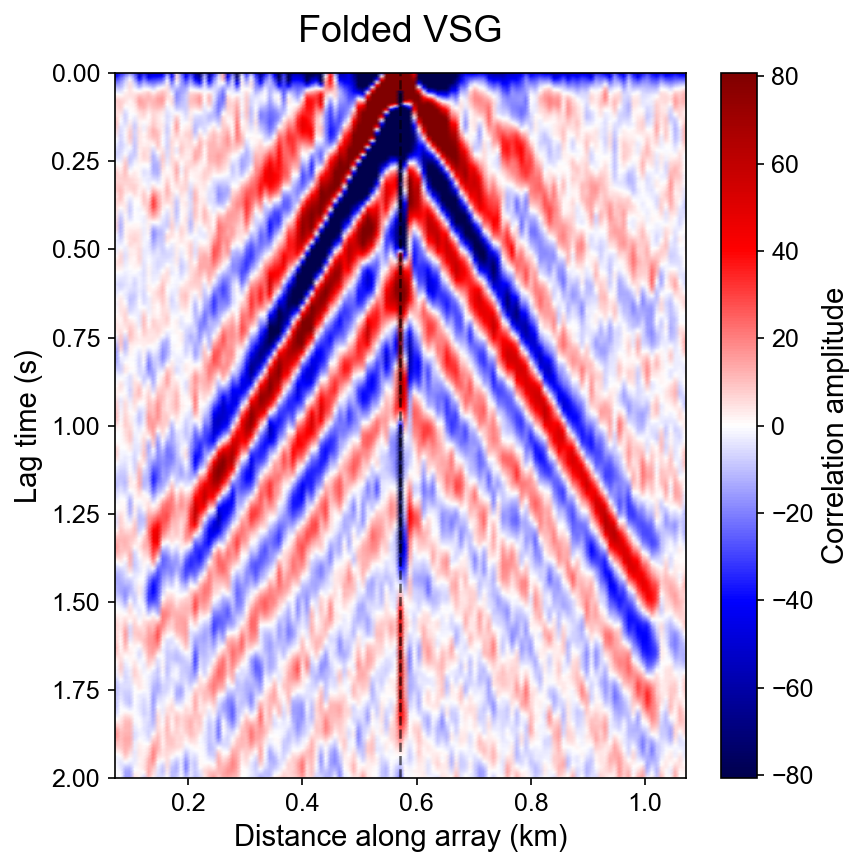

In [6]:
fig, ax = plot_directional_ncf(
    pattern=pattern_v1_15d,
    VS=70,                     
    lag_axis=lag_axis,
    distance_axis=distance_axis,
    target="s1",               
    view_side="both",          
    pos_offset=0.0,           
    unit="km",
    pclip=99,                
    dx=dx,
    range_m=500,                
    clip_lim=True,
    figsize=(6, 6),
    title="Folded VSG",
    show_cbar=True,
    dpi=150
)

plt.show()

In [ ]:
try:
    plt.rcParams.update({
        'figure.dpi': 120,        
        'savefig.dpi': 120,
        'axes.titlesize': 14,
    })

    ani_dir = animate_directional_ncf_section_mesh(
    pattern_v1_15d,
    lag_axis=lag_axis,
    distance_axis=distance_axis,
    target="s1",                
    unit="km",
    pclip=99,
    dx=dx,           
    range_m=500,               
    view_side="both",          
    pos_offset=0.0,            
    vs_start=None,               
    vs_end=None,                
    max_lag=None,              
)
    
    output = HTML(ani_dir.to_jshtml())

finally:
    plt.rcParams.update({
        'figure.dpi': old_fig_dpi,
        'savefig.dpi': old_save_dpi,
    })

display(output)

plt.close('all')
del ani_dir, output
gc.collect()

#### 3. Prepare NCFs Before Processing

In [7]:
output_folder = "../data/ncf_pre_urban"

export_targeted_ncfs(
    pattern_v1_15d,
    out_dir=output_folder,
    lag_axis=lag_axis,
    distance_axis=distance_axis,
    target="s1",                 
    dx=dx,
    range_m=500,              
    view_side="both",          
    pos_offset=0.0,            
    vs_start=None,              
    vs_end=None,               
    max_lag=2.0,                  
    taper_alpha=0.1               
)

export_targeted_ncfs(
    pattern_v1_15d,
    out_dir=output_folder,
    lag_axis=lag_axis,
    distance_axis=distance_axis,
    target="s2",                 
    dx=dx,
    range_m=500,              
    view_side="both",          
    pos_offset=0.0,            
    vs_start=None,              
    vs_end=None,               
    max_lag=2.0,                  
    taper_alpha=0.1               
)

Saving S1 gathers:   0%|          | 0/35 [00:00<?, ?it/s]

Saving S2 gathers:   0%|          | 0/35 [00:00<?, ?it/s]

#### 4. Display Pre-Processed NCFs

In [8]:
# Choose dataset
pattern_v1_15d_s1 = "../data/ncf_pre_urban/20210914_cc_*_15d_v1_s1.npz"
pattern_v1_15d_s2 = "../data/ncf_pre_urban/20210914_cc_*_15d_v1_s2.npz"

files_s1_v1 = sorted(glob.glob(pattern_v1_15d_s1), key=get_vs_number)
files_s2_v1 = sorted(glob.glob(pattern_v1_15d_s2), key=get_vs_number)
print("Matched files (s1):", len(files_s1_v1))
print("Matched files (s2):", len(files_s2_v1))
print("First 3 (s1):", files_s1_v1[:3])
print("First 3 (s2):", files_s2_v1[:3])

Matched files (s1): 35
Matched files (s2): 35
First 3 (s1): ['../data/ncf_pre_urban/20210914_cc_000_15d_v1_s1.npz', '../data/ncf_pre_urban/20210914_cc_010_15d_v1_s1.npz', '../data/ncf_pre_urban/20210914_cc_020_15d_v1_s1.npz']
First 3 (s2): ['../data/ncf_pre_urban/20210914_cc_000_15d_v1_s2.npz', '../data/ncf_pre_urban/20210914_cc_010_15d_v1_s2.npz', '../data/ncf_pre_urban/20210914_cc_020_15d_v1_s2.npz']


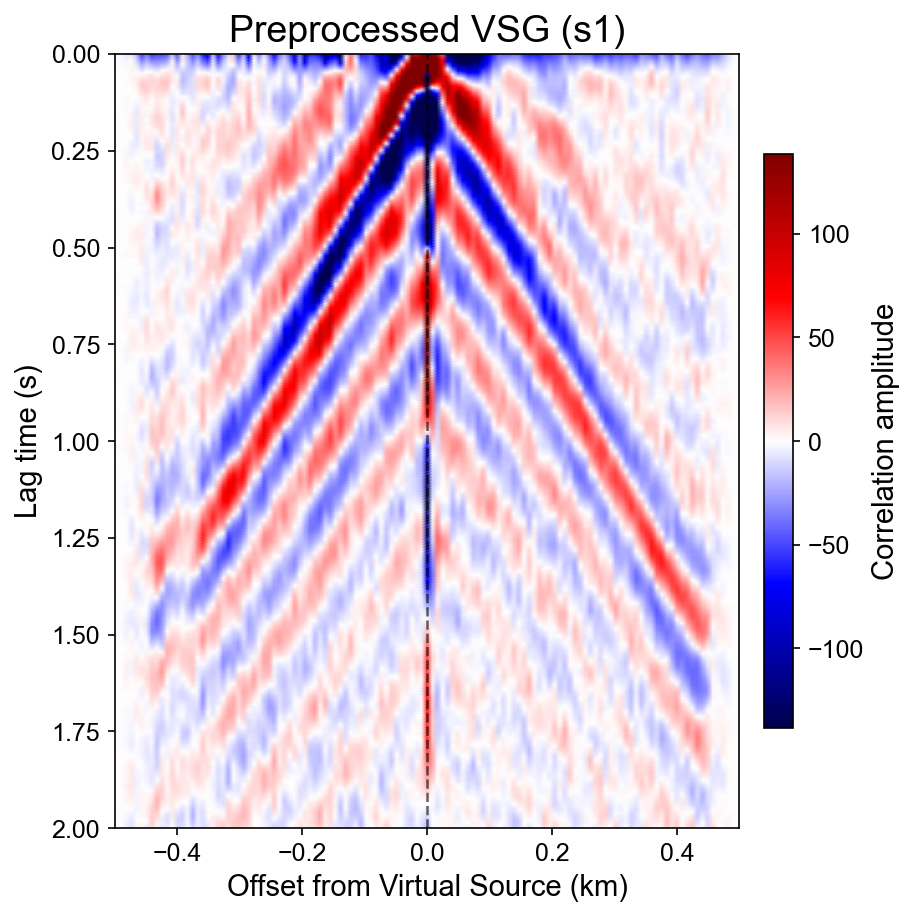

In [10]:
fig, ax = plot_preprocessed_ncf(
    files=files_s1_v1,          
    VS=70,                      
    unit="km",
    pclip=99.0,                
    range_m=500.0,             
    clip_lim=True,
    view_side="both",           
    pos_offset=0.0,            
    show_cbar=True,
    figsize=(6, 6),
    title="Preprocessed VSG (s1)",
    dpi=150
)

plt.show()

In [ ]:
try:
    plt.rcParams.update({
        'figure.dpi': 100,        
        'savefig.dpi': 100,
        'axes.titlesize': 14,
    })

    ani_pre = animate_preprocessed_ncf(
    files=files_s1_v1,           
    unit="km",
    pclip=99,
    range_m=500,             
    view_side="both",          
    pos_offset=0.0,           
)
    
    output = HTML(ani_pre.to_jshtml())

finally:
    plt.rcParams.update({
        'figure.dpi': old_fig_dpi,
        'savefig.dpi': old_save_dpi,
    })

display(output)

plt.close('all')
del ani_pre, output
gc.collect()

#### 5. Display f-k NCFs

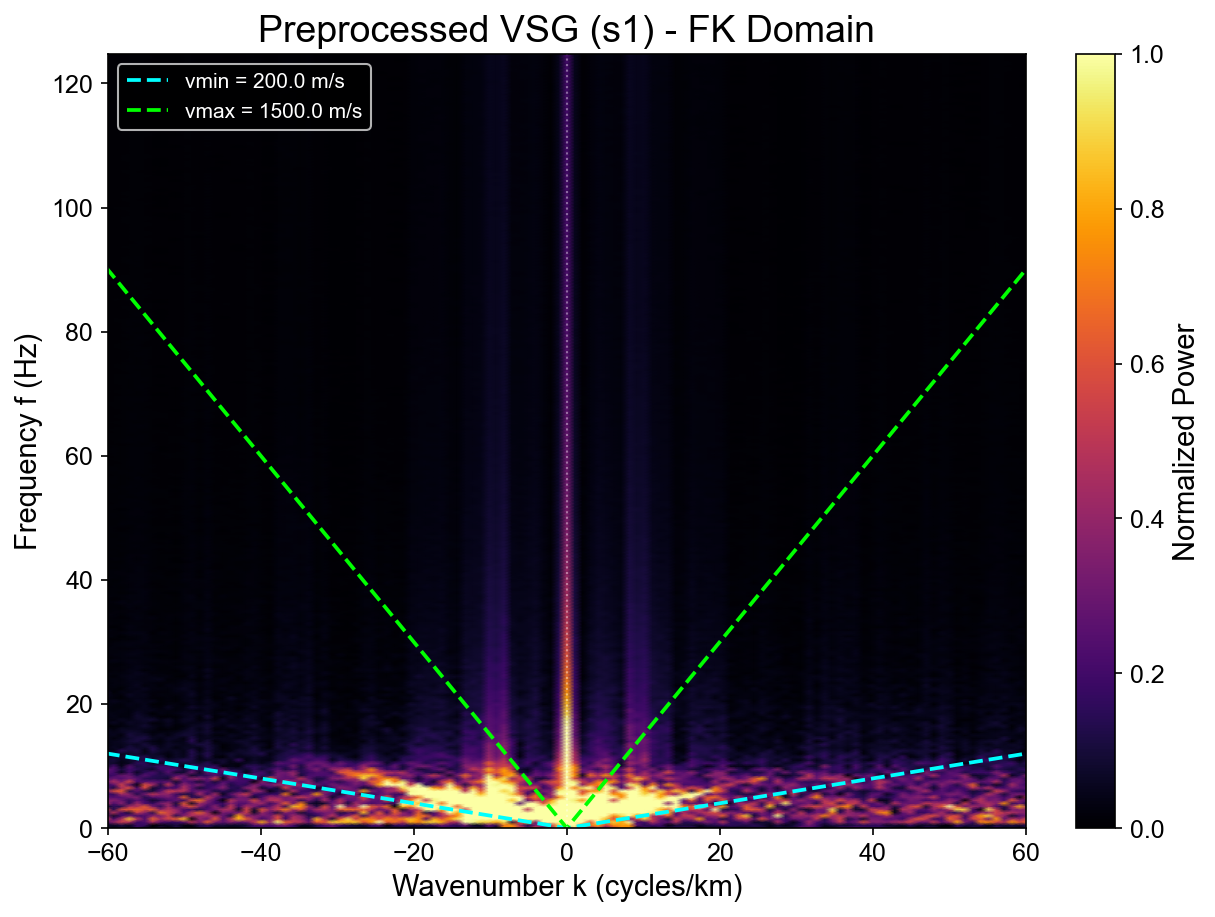

In [11]:
fig, ax = plot_preprocessed_fk(
    files=files_s1_v1,          
    VS=70,                      
    unit="km",                 
    pclip=99.0,                 
    cmap="inferno",            
    view_side="both",          
    pos_offset=10.0,           # Exclude the first 10m to avoid spatial aliasing near the source
    klim=(-60, 60),           
    figsize=(8, 6),
    title="Preprocessed VSG (s1) - FK Domain",
    vmin=200.0,                # Overlay a line representing 200 m/s
    vmax=1500.0,               # Overlay a line representing 1500 m/s
    show_cbar=True,
    dpi=150
)

plt.show()

In [ ]:
try:
    plt.rcParams.update({
        'figure.dpi': 120,        
        'savefig.dpi': 120,
        'axes.titlesize': 14,
    })

    ani_fk = animate_preprocessed_fk(
    files=files_s1_v1,
    unit="km",
    pclip=99.5,                
    view_side="both",
    pos_offset=10.0,
    klim=(-60, 60),              
    figsize=(9, 6),                           
    vmin=100,                  
    vmax=2000,                  
    interval_ms=200
)
    
    output = HTML(ani_fk.to_jshtml())

finally:
    plt.rcParams.update({
        'figure.dpi': old_fig_dpi,
        'savefig.dpi': old_save_dpi,
    })

display(output)

plt.close('all')
del ani_fk, output
gc.collect()

#### 6. NCF Processing: fk + Mute + Taper

In [ ]:
data_dir = "../data/ncf_pre_urban"
processed_out_dir = "../data/ncf_fk_urban/"
os.makedirs(processed_out_dir, exist_ok=True)

pattern_v1_15d_s1 = os.path.join(data_dir, "20210914_cc*_15d_v1_s1.npz")
pattern_v1_15d_s2 = os.path.join(data_dir, "20210914_cc*_15d_v1_s2.npz")

files_s1_v1 = sorted(glob.glob(pattern_v1_15d_s1), key=get_vs_number)
files_s2_v1 = sorted(glob.glob(pattern_v1_15d_s2), key=get_vs_number)

processing_queue = [
    (files_s1_v1, "s1_v1_urban.mp4", "S1"),
    (files_s2_v1, "s2_v1_urban.mp4", "S2"), 
]

for file_list, mp4_name, label in processing_queue:
    if not file_list:
        print(f"Skipping {label}: No files matched the pattern.")
        continue
        
    print(f"\n{'='*50}")
    print(f"🚀 STARTING PIPELINE: {label} ({len(file_list)} files)")
    print(f"{'='*50}")
    print(f"First 3: {[os.path.basename(f) for f in file_list[:3]]}")
    print(f"Last 3:  {[os.path.basename(f) for f in file_list[-3:]]}")

    # 1. Generate the animation object 
    anim_plot = animate_pipeline(
        file_list=file_list, 
        out_dir=None, 
        vmin=100.0, 
        vmax=2000.0,
        sigma=3.0, 
        vmax_time=None,   #1000.0   # Time Group Velocity (Slopes the top mute down tighter)
        pos_offset=10.0,
        inner_taper=10.0,
        range_m=500.0,
        pclip=99.0,
        interval=1000, 
        buffer_start_s=0.1, #0.02,
        buffer_end_s=2, #0.8,
        top_flat_m=10, 
        max_lag=1.8
    )

    # 2. Save the MP4 
    print(f"\nSaving video to [{mp4_name}]...")
    print("This will take a few minutes. Watch the progress bar below:")
    
    anim_plot.save(
        mp4_name, 
        fps=2, 
        dpi=150, 
        extra_args=['-vcodec', 'libx264'] 
    )

    print(f"\n✅ Video Render Complete for {label}!")

    plt.close('all')
    del anim_plot
    gc.collect()

print("\n🎉 All validation datasets rendered successfully.")

In [13]:
# Process and save NCFs (fk + mute + taper)
# Define Paths
data_dir = "../data/ncf_pre_urban"
processed_out_dir = "../data/ncf_fk_urban"

pattern_v1_s1 = os.path.join(data_dir, "20210914_cc*_15d_v1_s1.npz")
pattern_v1_s2 = os.path.join(data_dir, "20210914_cc*_15d_v1_s2.npz")

files_s1_v1 = sorted(glob.glob(pattern_v1_s1), key=get_vs_number)
files_s2_v1 = sorted(glob.glob(pattern_v1_s2), key=get_vs_number)

print(f"Found {len(files_s1_v1)} S1 files and {len(files_s2_v1)} S2 files.")

if files_s1_v1:
    print("\n--- Processing S1 ---")
    fast_batch_processor(files_s1_v1, processed_out_dir, vmin=100.0, vmax=2000.0, sigma=3.0, vmax_time=1000.0, pos_offset=10.0, inner_taper=10.0, range_m=500.0, buffer_start_s=0.1, buffer_end_s=2, top_flat_m=10.0, max_lag=1.8)

if files_s2_v1:
    print("\n--- Processing S2 ---")
    fast_batch_processor(files_s2_v1, processed_out_dir, vmin=100.0, vmax=2000.0, sigma=3.0, vmax_time=1000.0, pos_offset=10.0, inner_taper=10.0, range_m=500.0, buffer_start_s=0.1, buffer_end_s=2, top_flat_m=10.0, max_lag=1.8)

print(f"\n✅ All files successfully processed and saved to {processed_out_dir}")

Found 35 S1 files and 35 S2 files.

--- Processing S1 ---


Processing & Saving NCFs:   0%|          | 0/35 [00:00<?, ?it/s]


--- Processing S2 ---


Processing & Saving NCFs:   0%|          | 0/35 [00:00<?, ?it/s]


✅ All files successfully processed and saved to ../data/ncf_fk_urban


#### 7. Display Processed NCFs

In [14]:
pattern_v1_15d_fk_s1 = "../data/ncf_fk_urban/20210914_cc*_15d_v1_s1_fk_*_*.npz"
files_s1_v1_fk = sorted(glob.glob(pattern_v1_15d_fk_s1), key=get_vs_number)
print(f"Matched files (S1): {len(files_s1_v1_fk)}")

if files_s1_v1_fk:
    print(f"First 3 (S1): {[os.path.basename(f) for f in files_s1_v1_fk[:3]]}")


Matched files (S1): 35
First 3 (S1): ['20210914_cc_000_15d_v1_s1_fk_100_2000.npz', '20210914_cc_010_15d_v1_s1_fk_100_2000.npz', '20210914_cc_020_15d_v1_s1_fk_100_2000.npz']


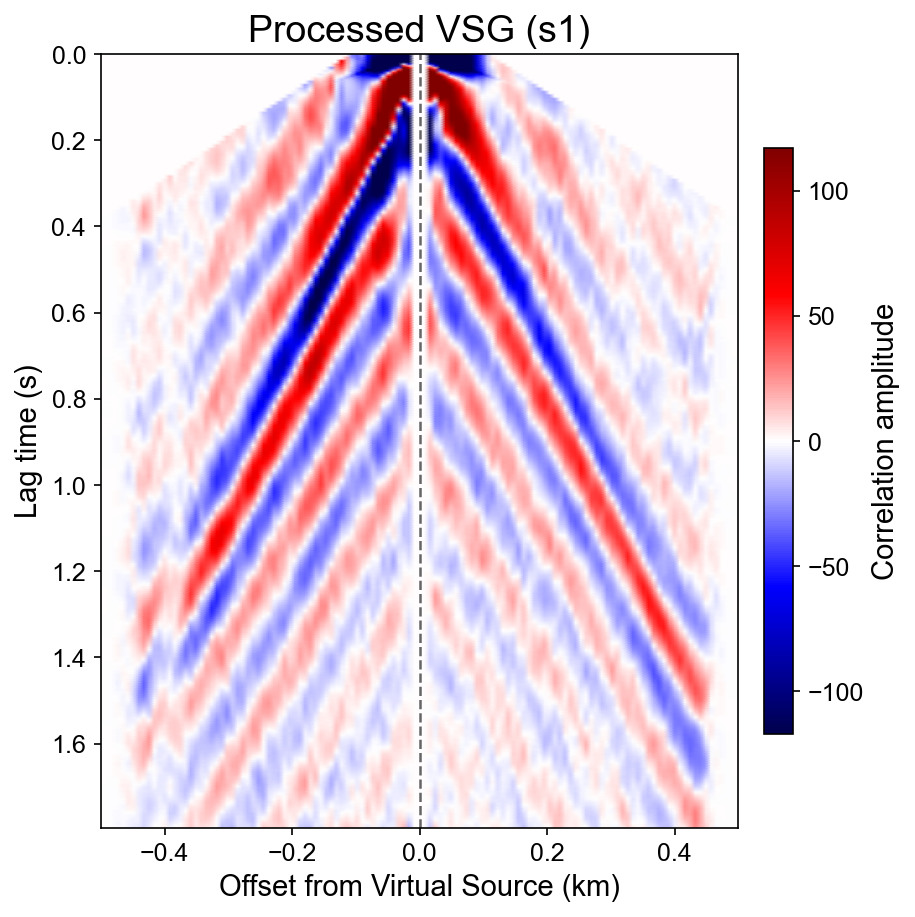

In [17]:
fig, ax = plot_preprocessed_ncf(
    files=files_s1_v1_fk,          
    VS=70,                      
    unit="km",
    pclip=99.0,                
    range_m=500.0,             
    clip_lim=True,
    view_side="both",           
    pos_offset=0.0,            
    show_cbar=True,
    figsize=(6, 6),
    title="Processed VSG (s1)",
    dpi=150
)

plt.show()

In [ ]:
if files_s1_v1_fk:
    try:
        plt.rcParams.update({
            'figure.dpi': 100,        
            'savefig.dpi': 100,
            'axes.titlesize': 14,
        })

        ani_pre = animate_preprocessed_ncf(
        files=files_s1_v1_fk,           
        unit="m",
        pclip=99,
        range_m=500.0,             
        view_side="both",          
        pos_offset=0.0,           
        )
        
        output = HTML(ani_pre.to_jshtml())

    finally:
        plt.rcParams.update({
            'figure.dpi': old_fig_dpi,
            'savefig.dpi': old_save_dpi,
        })

display(output)

plt.close('all')
del ani_pre, output
gc.collect()

#### 8. Choose Good VS

In [16]:
# 1. Define Paths and Patterns
data_dir = "../data/ncf_fk_urban"
out_dir = "../data/ncf_disp_urban"
os.makedirs(out_dir, exist_ok=True)

pattern_v1_s1_fk = os.path.join(data_dir, "20210914_cc*_15d_v1_s1_fk_*_*.npz")
pattern_v1_s2_fk = os.path.join(data_dir, "20210914_cc*_15d_v1_s2_fk_*_*.npz")

files_s1_v1_fk = sorted(glob.glob(pattern_v1_s1_fk), key=get_vs_number)
files_s2_v1_fk = sorted(glob.glob(pattern_v1_s2_fk), key=get_vs_number)

# 2. Batch Execution Queue
# Add or remove datasets from this list to control what runs
processing_queue = [
    (files_s1_v1_fk, "S1"),
    (files_s2_v1_fk, "S2"), 
]

total_saved = 0

for file_list, label in processing_queue:
    if not file_list:
        print(f"⏭️ Skipping {label}: No files matched the pattern.")
        continue

    print(f"\n{'='*50}")
    print(f"🚀 SPLITTING SIDES: {label} ({len(file_list)} files)")
    print(f"{'='*50}")
    print(f"First 3: {[os.path.basename(f) for f in file_list[:3]]}")

    # Build Dask Task Graph
    tasks = [split_ncf_sides_for_dispersion(path, out_dir) for path in file_list]

    print(f"\nDispatching {len(tasks)} files to Dask workers...")

    # Execute with Progress Bar
    with ProgressBar():
        results = dask.compute(*tasks)

    # Cleanly flatten the list of lists and remove Nones
    final_paths = [path for res in results if res is not None for path in res]
    total_saved += len(final_paths)

    print(f"✅ Finished {label}. Saved {len(final_paths)} directional files.")

print(f"\n🎉 Process Complete! Total directional files saved to {out_dir}: {total_saved}")


🚀 SPLITTING SIDES: S1 (35 files)
First 3: ['20210914_cc_000_15d_v1_s1_fk_100_2000.npz', '20210914_cc_010_15d_v1_s1_fk_100_2000.npz', '20210914_cc_020_15d_v1_s1_fk_100_2000.npz']

Dispatching 35 files to Dask workers...
[########################################] | 100% Completed | 101.39 ms
✅ Finished S1. Saved 69 directional files.

🚀 SPLITTING SIDES: S2 (35 files)
First 3: ['20210914_cc_000_15d_v1_s2_fk_100_2000.npz', '20210914_cc_010_15d_v1_s2_fk_100_2000.npz', '20210914_cc_020_15d_v1_s2_fk_100_2000.npz']

Dispatching 35 files to Dask workers...
[########################################] | 100% Completed | 104.28 ms
✅ Finished S2. Saved 69 directional files.

🎉 Process Complete! Total directional files saved to ../data/ncf_disp_urban: 138


**Convert notebook to html**
```bash
python3 -m jupyter nbconvert --to html vsg_urban.ipynb
```